# SF Data Cleaning Notebook - Initial (Ibrahim)

In [43]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile

## The `load_data()` function

- Loads in the sf data and the [geojson file](https://data.sfgov.org/Geographic-Locations-and-Boundaries/Bay-Area-County-Polygons/wamw-vt4s/data_preview)
- Converts the sf data to have valid coordinates
- Returns both files

In [44]:
def load_data(sf_path, geo_path):
    
    # Run SF data
    with zipfile.ZipFile(sf_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        df = pd.read_csv(z.open(csv_file))

    # Run Geo csv
    sf = gpd.read_file(geo_path)
    
    # Convert Geo csv
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lng"], df["lat"]),
        crs="EPSG:4326"
    )
    
    # Debug
    print("Shapefile CRS:", sf.crs)
    print("Points CRS:", gdf.crs)
    
    return sf, gdf

# Paths need changing based on your setup
local_path = r"c:\Users\madel\Downloads\SDS 357 Term Project"

sf_path = local_path + r"\sds357-project-sp26-con-founders\data\sf_police_stops_raw.csv.zip"
geo_path = local_path + r"\sds357-project-sp26-con-founders\Preprocessing\Bay_Area_County_Polygons_20260206.geojson"
sf, gdf = load_data(sf_path, geo_path)
gdf.head()

C:\Users\madel\AppData\Local\Temp\ipykernel_25864\1233617752.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(csv_file))


Shapefile CRS: EPSG:4326
Points CRS: EPSG:4326


,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,warning_issued,outcome,contraband_found,search_conducted,search_vehicle,search_basis,reason_for_stop,raw_search_vehicle_description,raw_result_of_contact_description,geometry
0,869921,2014-08-01,00:01:00,MASONIC AV & FELL ST,37.773004,-122.445873,NaN,NaN,asian/pacific islander,female,...,True,warning,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Warning,POINT (-122.44587 37.773)
1,869922,2014-08-01,00:01:00,GEARY&10TH AV,37.780898,-122.468586,NaN,NaN,black,male,...,False,citation,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Citation,POINT (-122.46859 37.7809)
2,869923,2014-08-01,00:15:00,SUTTER N OCTAVIA ST,37.786919,-122.426718,NaN,NaN,hispanic,male,...,False,citation,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Citation,POINT (-122.42672 37.78692)
3,869924,2014-08-01,00:18:00,3RD ST & DAVIDSON,37.746380,-122.392005,NaN,NaN,hispanic,male,...,True,warning,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Warning,POINT (-122.392 37.74638)
4,869925,2014-08-01,00:19:00,DIVISADERO ST. & BUSH ST.,37.786348,-122.440003,NaN,NaN,white,male,...,False,citation,NaN,False,False,NaN,Mechanical or Non-Moving Violation (V.C.),No Search,Citation,POINT (-122.44 37.78635)


## Initial Plot (Before preprocessing)

We can see that there are many incorrect coordinates that don't line up with the boundary of SF.

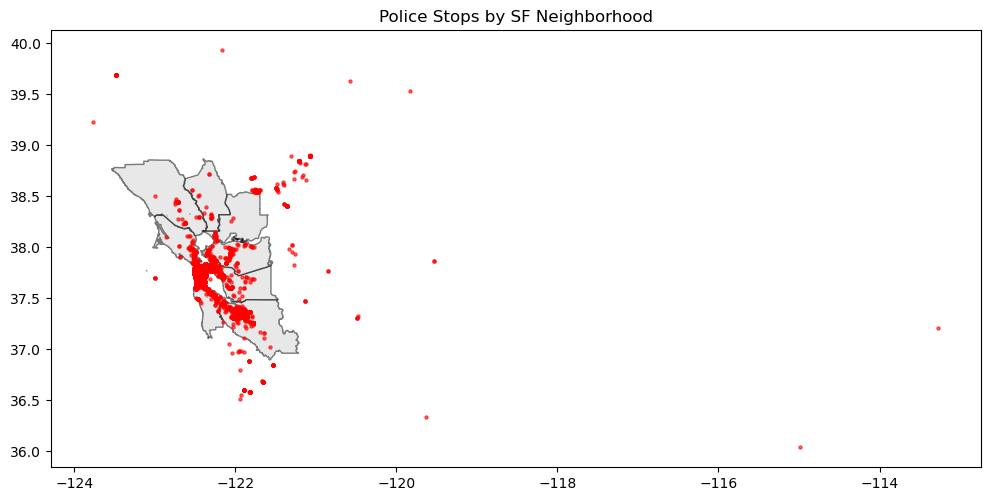

In [45]:
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
gdf.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()

We can see here that the bounds of the points don't match with the geojson file

In [46]:
# Check a few coordinates
print(gdf.head()[['geometry']])
print("\nBounds of shapefile:", sf.total_bounds)
print("Bounds of points:", gdf.total_bounds)

                      geometry
0    POINT (-122.44587 37.773)
1   POINT (-122.46859 37.7809)
2  POINT (-122.42672 37.78692)
3    POINT (-122.392 37.74638)
4     POINT (-122.44 37.78635)

Bounds of shapefile: [-123.53367    36.894155 -121.208178   38.864245]
Bounds of points: [-123.7674293   36.038676  -113.2681513   39.929646 ]


In [47]:
print("Total points:", len(gdf))
print("Points outside shapefile bounds:", 
      ((gdf.geometry.x < -123.6) | (gdf.geometry.x > -121.0) |
       (gdf.geometry.y < 36.8) | (gdf.geometry.y > 39.0)).sum())

Total points: 905070
Points outside shapefile bounds: 97


## Preprocess Non Location Variables

In [48]:
#View number of variable outcome per variable of intreset
#suggests dropping search_basis and contraband_found
variables = ['district', 'outcome', 'subject_race', 'subject_sex', 'type', 'reason_for_stop', 'raw_search_vehicle_description', 'raw_result_of_contact_description']

for v in variables:
    print(gdf.groupby(v).size())

district
A     69677
B    105867
C     95406
D     87702
E     73846
F     61713
G     85276
H    117520
I    108213
J     46171
K       783
S       514
T       195
dtype: int64
outcome
arrest       11925
citation    631602
warning     245862
dtype: int64
subject_race
asian/pacific islander    157684
black                     152196
hispanic                  116014
other                     106858
white                     372318
dtype: int64
subject_sex
female    265851
male      639219
dtype: int64
type
vehicular    905070
dtype: int64
reason_for_stop
Assistance to Motorist                                                                                                                                                                         930
BOLO/APB/Warrant                                                                                                                                                                              1207
DUI Check                                         

Based on tabling, the following is suggested:
*  Only keep following for raw vehicle description: 'Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search'
*  Only keep following for reason for stop: 'Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist'

Note the raw vehicle description helps dervive search outcome (based on if it's postive or negative outcome)

In [49]:
#Filter out values in raw vehicle description
raw_vehicle_desc_keep = ['Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search']
gdf_filtered = gdf[gdf['raw_search_vehicle_description'].isin(raw_vehicle_desc_keep)]

raw_reason_for_stop = ['Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist']
gdf_filtered = gdf_filtered[gdf_filtered['reason_for_stop'].isin(raw_reason_for_stop)]

Now lets filter out NA in  'subject_age', 'time', 'district'

In [53]:
gdf_filtered = gdf_filtered.dropna(subset = ['subject_age', 'time', 'district'])

In [54]:
gdf_filtered.head()

,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,warning_issued,outcome,contraband_found,search_conducted,search_vehicle,search_basis,reason_for_stop,raw_search_vehicle_description,raw_result_of_contact_description,geometry
33160,31,2007-01-01,10:17:00,EMBARCADERO & HOWARDA ON,37.792563,-122.390973,B,32.0,white,male,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.39097 37.79256)
33161,32,2007-01-01,10:25:00,1700 JUDAH,37.761562,-122.480251,I,57.0,asian/pacific islander,female,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.48025 37.76156)
33162,33,2007-01-01,10:28:00,COLUMBUS/VALLEJO,37.798712,-122.407910,A,31.0,hispanic,male,...,True,warning,NaN,False,False,NaN,Moving Violation,No Search,Warning,POINT (-122.40791 37.79871)
33163,34,2007-01-01,10:35:00,FOLSOM & MOSS,37.777182,-122.407335,J,37.0,hispanic,female,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.40734 37.77718)
33164,35,2007-01-01,10:40:00,WASHINGTON/VAN NESS,37.793076,-122.422808,E,39.0,asian/pacific islander,female,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.42281 37.79308)


## The `fix_coordinates()` function (Preprocess Location)

- Takes in the `gdf` and the `sf`
- Calculates the boundds of the `sf`
- Filters out points in the `gdf` that don't fit in the `sf`
- Returns a `gdf_clean`

There needs to be more research in this section. There are still some points that don't line up (not sure why). Maybe look into the data set if they have anything in common and if they will be filtered out when we narrow down our data set to see the impact of Vision Zero.

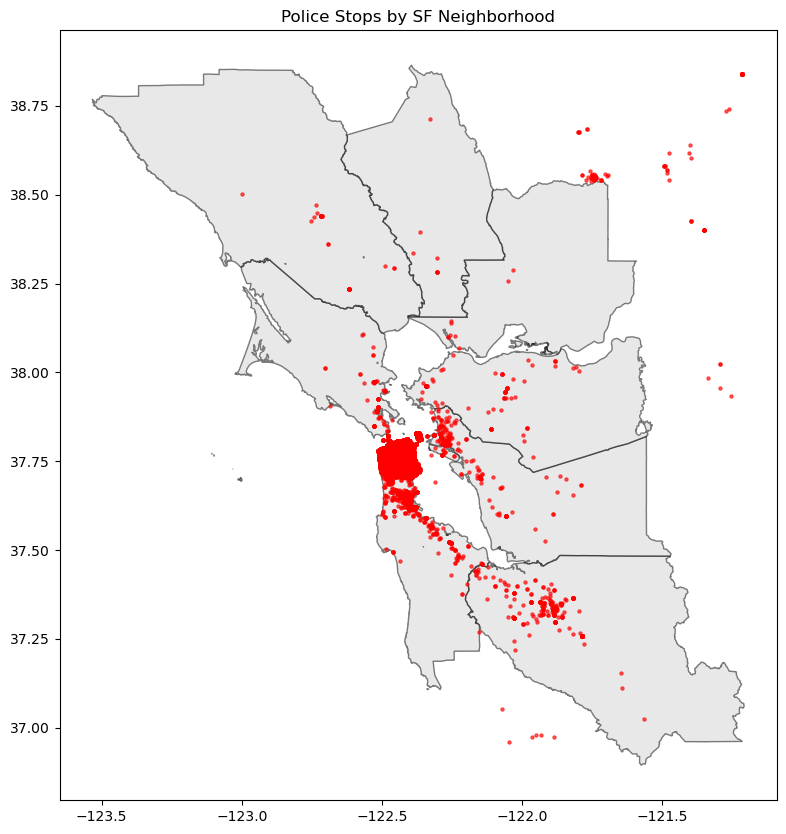

In [55]:
def fix_coordinates(gdf, sf):
    
    # Get sf (geojson bounds) and filter points
    minx, miny, maxx, maxy = sf.total_bounds
    gdf_clean = gdf[
    (gdf.geometry.x >= minx) & 
    (gdf.geometry.x <= maxx) &
    (gdf.geometry.y >= miny) & 
    (gdf.geometry.y <= maxy)
]
    
    return gdf_clean

gdf_clean = fix_coordinates(gdf_filtered, sf)

# Now plot with clean data
fig, ax = plt.subplots(figsize=(12, 10))
sf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
gdf_clean.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()   